## Segmentation RFM 

In [1]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

### Connexion à la DB / Import des Data


In [2]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [3]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 3 tables in the database:

1. all_events
2. loaded_files
3. user_events


In [4]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────┐
│     name     │
│   varchar    │
├──────────────┤
│ all_events   │
│ loaded_files │
│ user_events  │
└──────────────┘



In [5]:
# Show count of records in user_segments
user_segments_data = con.sql("""
    SELECT *
    FROM user_events
    ORDER BY RANDOM()
    LIMIT 10000
""")
user_segments_data.show()

# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate   │   purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │       double        │       double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼─────────────────────┼─────────────────────┼───────────────────────┤
│ 611299984 │           17 │        16.0 │             0.0 │              59356.1875 │                0.0 │                0

In [6]:
user_segments_df_tmspt = user_segments_data.df()

In [7]:
user_segments_df = user_segments_data.df()

In [8]:
user_segments_df_tmspt.columns

Index(['user_id', 'total_events', 'total_views', 'total_purchases',
       'avg_time_between_events', 'total_spent', 'avg_basket',
       'last_event_time', 'conversion_rate', 'purchase_ratio',
       'days_since_last_event'],
      dtype='object')

In [9]:
# Check basic statistics and missing values
print("Basic statistics of the dataset:")
print(f"Number of users: {len(user_segments_df_tmspt)}")
print(f"Number of columns: {len(user_segments_df_tmspt.columns)}")
print("\nMissing values per column:")
print(user_segments_df_tmspt.isna().sum())

# Generate descriptive statistics
print("\nDescriptive statistics:")
user_segments_df_tmspt_stats = user_segments_df_tmspt.describe()
user_segments_df_tmspt_stats

Basic statistics of the dataset:
Number of users: 5989
Number of columns: 11

Missing values per column:
user_id                    0
total_events               0
total_views                0
total_purchases            0
avg_time_between_events    0
total_spent                0
avg_basket                 0
last_event_time            0
conversion_rate            0
purchase_ratio             0
days_since_last_event      0
dtype: int64

Descriptive statistics:


,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
count,5989.000000,5989.000000,5989.000000,5989.000000,5989.000000,5989.000000,5989,5989.000000,5989.000000,5989.000000
mean,40.682919,37.775756,0.857572,39006.146634,270.764004,69.772390,2020-02-20 05:37:59.543830,0.038693,0.028973,40.240608
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2020-02-01 01:59:02,0.000000,0.000000,30.000000
25%,14.000000,13.000000,0.000000,5222.062500,0.000000,0.000000,2020-02-15 14:41:58,0.000000,0.000000,34.000000
50%,22.000000,20.000000,0.000000,24674.235294,0.000000,0.000000,2020-02-21 20:16:29,0.000000,0.000000,39.000000
75%,41.000000,38.000000,0.000000,56135.882353,0.000000,0.000000,2020-02-26 00:54:22,0.000000,0.000000,45.000000
max,10150.000000,10150.000000,86.000000,266247.111111,31853.330000,2504.700000,2020-02-29 23:54:53,3.000000,0.750000,59.000000
std,159.709327,158.804412,3.224134,44211.967018,1309.019153,194.851263,NaN,0.119068,0.074977,7.272080


In [10]:
user_segments_df_tmspt_stats["avg_time_between_events"]

count      5989.000000
mean      39006.146634
min           0.000000
25%        5222.062500
50%       24674.235294
75%       56135.882353
max      266247.111111
std       44211.967018
Name: avg_time_between_events, dtype: float64

In [11]:
user_segments_df_tmspt_stats["days_since_last_event"]

count    5989.000000
mean       40.240608
min        30.000000
25%        34.000000
50%        39.000000
75%        45.000000
max        59.000000
std         7.272080
Name: days_since_last_event, dtype: float64

In [12]:
user_segments_df_tmspt['days_since_last_event']

0       51
1       35
2       41
3       58
4       57
        ..
5984    46
5985    40
5986    40
5987    31
5988    51
Name: days_since_last_event, Length: 5989, dtype: int64

In [13]:
user_segments_df_tmspt

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,530092249,10,10.0,0.0,22053.000000,0.00,0.00,2020-02-09 10:50:24,0.000000,0.000000,51
1,609755176,24,23.0,0.0,82866.130435,0.00,0.00,2020-02-25 07:44:24,0.000000,0.000000,35
2,616080818,19,19.0,0.0,10934.333333,0.00,0.00,2020-02-19 10:39:21,0.000000,0.000000,41
3,609558338,11,11.0,0.0,80.900000,0.00,0.00,2020-02-02 16:42:22,0.000000,0.000000,58
4,518552508,14,5.0,0.0,5.307692,0.00,0.00,2020-02-03 16:18:42,0.000000,0.000000,57
...,...,...,...,...,...,...,...,...,...,...,...
5984,545582731,14,14.0,0.0,197.076923,0.00,0.00,2020-02-14 19:02:30,0.000000,0.000000,46
5985,523896882,11,11.0,0.0,48818.000000,0.00,0.00,2020-02-20 03:54:08,0.000000,0.000000,40
5986,522839934,37,37.0,0.0,3699.555556,0.00,0.00,2020-02-20 09:27:48,0.000000,0.000000,40
5987,512417760,209,205.0,1.0,11461.408654,139.02,139.02,2020-02-29 08:16:58,0.004878,0.004854,31


In [14]:
print(user_segments_df_tmspt['last_event_time'].iloc[0:5])
print(type(user_segments_df_tmspt['last_event_time'].iloc[0]))

0   2020-02-09 10:50:24
1   2020-02-25 07:44:24
2   2020-02-19 10:39:21
3   2020-02-02 16:42:22
4   2020-02-03 16:18:42
Name: last_event_time, dtype: datetime64[us]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [15]:
# Conversion des jours en mois (approximation: 30 jours = 1 mois)
user_segments_df_tmspt['months_since_last_event'] = user_segments_df_tmspt['days_since_last_event'] / 30

In [16]:
def perform_rfm_analysis(df, 
                        r_column='months_since_last_event',
                        r_thresholds=[1, 5],
                        r_scores=[2, 1, 0],
                        f_column='total_purchases',
                        f_thresholds=[2, 10],
                        f_scores=[0, 1, 2],
                        m_column='total_spent',
                        m_thresholds=[20, 50],
                        m_scores=[0, 1, 2],
                        segment_thresholds=[0, 2, 3, 4, 6],
                        segment_names=['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions'],
                        days_to_months=30,
                        visualize=True):
    """
    Réalise une analyse RFM complète avec des seuils et critères personnalisables
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données client
        r_column (str): Nom de la colonne pour la récence
        r_thresholds (list): Seuils pour la récence (ex: [1, 5] pour <1 mois, 1-5 mois, >5 mois)
        r_scores (list): Scores à attribuer pour chaque segment de récence
        f_column (str): Nom de la colonne pour la fréquence
        f_thresholds (list): Seuils pour la fréquence (ex: [2, 10] pour <2, 2-10, >10)
        f_scores (list): Scores à attribuer pour chaque segment de fréquence
        m_column (str): Nom de la colonne pour le montant
        m_thresholds (list): Seuils pour le montant (ex: [20, 50] pour <20€, 20-50€, >50€)
        m_scores (list): Scores à attribuer pour chaque segment de montant
        segment_thresholds (list): Seuils pour les segments client basés sur le score RFM total
        segment_names (list): Noms des segments clients
        days_to_months (int): Facteur de conversion jours en mois (si applicable)
        visualize (bool): Afficher les graphiques
    
    Returns:
        pd.DataFrame: DataFrame original avec les scores et segments RFM ajoutés
    """
    # Créer une copie du dataframe pour ne pas modifier l'original
    df_rfm = df.copy()
    
    # Convertir days_since_last_event en months_since_last_event si nécessaire
    if r_column == 'months_since_last_event' and 'days_since_last_event' in df_rfm.columns and 'months_since_last_event' not in df_rfm.columns:
        df_rfm['months_since_last_event'] = df_rfm['days_since_last_event'] / days_to_months
    
    # Fonction pour assigner les scores selon les critères et seuils
    def assign_score(value, thresholds, scores):
        if len(thresholds) + 1 != len(scores):
            raise ValueError("Le nombre de scores doit être égal au nombre de seuils + 1")
        
        # Vérifier dans quelle plage se trouve la valeur
        for i, threshold in enumerate(thresholds):
            if value < threshold:
                return scores[i]
        
        # Si la valeur est supérieure à tous les seuils, retourner le dernier score
        return scores[-1]
    
    # Appliquer les fonctions de score
    df_rfm['R_score'] = df_rfm[r_column].apply(lambda x: assign_score(x, r_thresholds, r_scores))
    df_rfm['F_score'] = df_rfm[f_column].apply(lambda x: assign_score(x, f_thresholds, f_scores))
    df_rfm['M_score'] = df_rfm[m_column].apply(lambda x: assign_score(x, m_thresholds, m_scores))
    
    # Créer un score RFM combiné (comme une chaîne de caractères)
    df_rfm['RFM_segment'] = df_rfm['R_score'].astype(str) + \
                           df_rfm['F_score'].astype(str) + \
                           df_rfm['M_score'].astype(str)
    
    # Calculer le score RFM total
    df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']
    
    # Fonction pour attribuer un segment en fonction du score RFM total
    def assign_segment(score, thresholds, names):
        if len(thresholds) != len(names):
            raise ValueError("Le nombre de noms de segments doit être égal au nombre de seuils")
            
        for i in range(len(thresholds)-1):
            if thresholds[i] <= score < thresholds[i+1]:
                return names[i]
                
        return names[-1]  # Dernier segment si score >= dernier seuil
    
    # Attribuer les segments
    df_rfm['segment'] = df_rfm['RFM_score'].apply(lambda x: assign_segment(x, segment_thresholds, segment_names))
    
    # Afficher les résultats
    print("RFM Analysis Completed")
    print(f"Total clients segmentés: {len(df_rfm)}")
    
    # Afficher la distribution des scores individuels
    print("\nDistribution des scores R:")
    r_dist = df_rfm['R_score'].value_counts().sort_index()
    print(r_dist)
    
    print("\nDistribution des scores F:")
    f_dist = df_rfm['F_score'].value_counts().sort_index()
    print(f_dist)
    
    print("\nDistribution des scores M:")
    m_dist = df_rfm['M_score'].value_counts().sort_index()
    print(m_dist)
    
    print("\nDistribution des segments RFM:")
    print(df_rfm['RFM_segment'].value_counts())
    
    # Afficher les critères RFM utilisés
    print("\n--- CRITÈRES RFM UTILISÉS ---\n")
    
    # Récence
    print(f"RÉCENCE ({r_column}):")
    if len(r_thresholds) == 2:
        print(f"Score {r_scores[0]}: moins de {r_thresholds[0]}")
        print(f"Score {r_scores[1]}: entre {r_thresholds[0]} et {r_thresholds[1]}")
        print(f"Score {r_scores[2]}: plus de {r_thresholds[1]}")
    else:
        for i in range(len(r_scores)):
            if i == 0:
                print(f"Score {r_scores[i]}: moins de {r_thresholds[i]}")
            elif i == len(r_scores) - 1:
                print(f"Score {r_scores[i]}: plus de {r_thresholds[i-1]}")
            else:
                print(f"Score {r_scores[i]}: entre {r_thresholds[i-1]} et {r_thresholds[i]}")
    
    # Fréquence
    print(f"\nFRÉQUENCE ({f_column}):")
    if len(f_thresholds) == 2:
        print(f"Score {f_scores[0]}: moins de {f_thresholds[0]}")
        print(f"Score {f_scores[1]}: entre {f_thresholds[0]} et {f_thresholds[1]}")
        print(f"Score {f_scores[2]}: plus de {f_thresholds[1]}")
    else:
        for i in range(len(f_scores)):
            if i == 0:
                print(f"Score {f_scores[i]}: moins de {f_thresholds[i]}")
            elif i == len(f_scores) - 1:
                print(f"Score {f_scores[i]}: plus de {f_thresholds[i-1]}")
            else:
                print(f"Score {f_scores[i]}: entre {f_thresholds[i-1]} et {f_thresholds[i]}")
    
    # Montant
    print(f"\nMONTANT ({m_column}):")
    if len(m_thresholds) == 2:
        print(f"Score {m_scores[0]}: moins de {m_thresholds[0]}€")
        print(f"Score {m_scores[1]}: entre {m_thresholds[0]}€ et {m_thresholds[1]}€")
        print(f"Score {m_scores[2]}: plus de {m_thresholds[1]}€")
    else:
        for i in range(len(m_scores)):
            if i == 0:
                print(f"Score {m_scores[i]}: moins de {m_thresholds[i]}€")
            elif i == len(m_scores) - 1:
                print(f"Score {m_scores[i]}: plus de {m_thresholds[i-1]}€")
            else:
                print(f"Score {m_scores[i]}: entre {m_thresholds[i-1]}€ et {m_thresholds[i]}€")
    
    # Distribution des segments de clients
    print("\nDistribution des segments de clients:")
    segment_counts = df_rfm['segment'].value_counts()
    for segment, count in segment_counts.items():
        print(f"{segment}: {count} clients ({count/len(df_rfm)*100:.1f}%)")
    
    # Visualisation
    if visualize:
        # Visualisation des segments
        plt.figure(figsize=(10, 6))
        sns.countplot(x='segment', data=df_rfm, order=segment_counts.index)
        plt.title('Distribution des Segments Clients')
        plt.xlabel('Segment')
        plt.ylabel('Nombre de Clients')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Visualisation des scores R, F, M
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        sns.countplot(x='R_score', data=df_rfm, ax=axes[0])
        axes[0].set_title('Distribution des Scores R')
        axes[0].set_xlabel('Score R')
        axes[0].set_ylabel('Nombre de Clients')
        
        sns.countplot(x='F_score', data=df_rfm, ax=axes[1])
        axes[1].set_title('Distribution des Scores F')
        axes[1].set_xlabel('Score F')
        axes[1].set_ylabel('Nombre de Clients')
        
        sns.countplot(x='M_score', data=df_rfm, ax=axes[2])
        axes[2].set_title('Distribution des Scores M')
        axes[2].set_xlabel('Score M')
        axes[2].set_ylabel('Nombre de Clients')
        
        plt.tight_layout()
        plt.show()
    
    # Générer un tableau récapitulatif avec les caractéristiques de chaque segment
    print("\nCaractéristiques moyennes par segment:")
    segment_stats = df_rfm.groupby('segment').agg({
        r_column: 'mean',
        f_column: 'mean',
        m_column: 'mean',
        'R_score': 'mean',
        'F_score': 'mean',
        'M_score': 'mean',
        'RFM_score': 'mean',
        df_rfm.columns[0]: 'count'  # Utiliser la première colonne pour le comptage
    }).rename(columns={df_rfm.columns[0]: 'count'}).sort_values(by='RFM_score', ascending=False)
    
    segment_stats = segment_stats.round(2)
    display(segment_stats)
    
    return df_rfm



RFM Analysis Completed
Total clients segmentés: 5989

Distribution des scores R:
R_score
1    5989
Name: count, dtype: int64

Distribution des scores F:
F_score
0    5064
1     838
2      87
Name: count, dtype: int64

Distribution des scores M:
M_score
0    4553
1     136
2    1300
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
100    4546
112     807
102     406
101     112
122      87
111      24
110       7
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des segments de clients:
Clients Perdus: 4665 clients (77.9%)
Clients Potentiels: 807 clients (13.5%)
Clients à Risque: 430 clients (7.2%)
Clients Fidèles: 87 clients (1.5%)


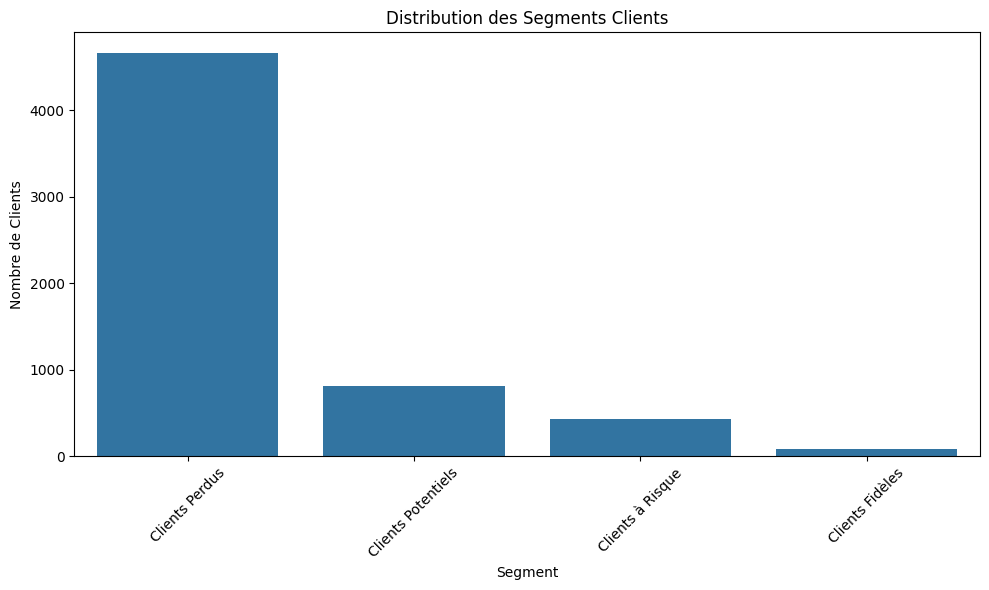

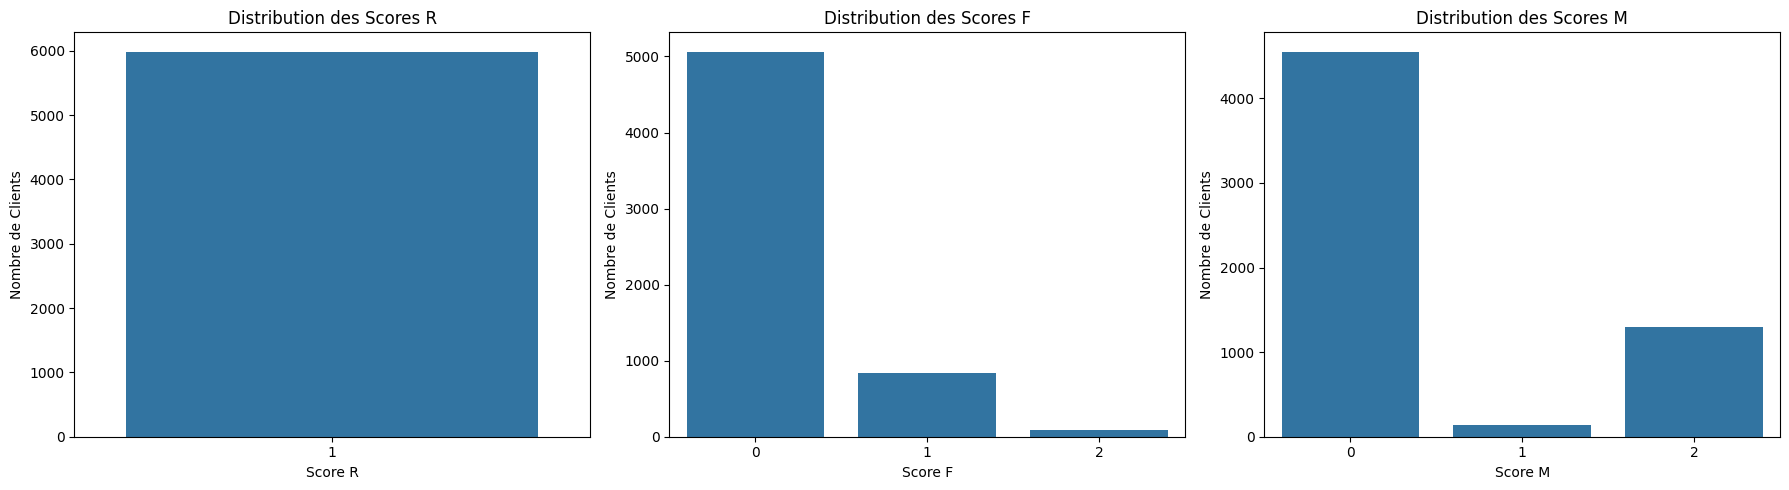


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Fidèles,1.23,20.90,7363.45,1.0,2.00,2.00,5.00,87
Clients Potentiels,1.34,3.35,1058.04,1.0,1.00,2.00,4.00,807
Clients à Risque,1.33,1.07,285.79,1.0,0.06,1.94,3.00,430
Clients Perdus,1.35,0.03,0.91,1.0,0.00,0.02,1.03,4665


"\nrfm_custom = perform_rfm_analysis(\n    user_segments_df,\n    r_column='months_since_last_event',\n    r_thresholds=[0.5, 2, 6],  # 4 segments de récence\n    r_scores=[3, 2, 1, 0],\n    f_column='total_purchases',\n    f_thresholds=[1, 5, 15],  # 4 segments de fréquence\n    f_scores=[0, 1, 2, 3],\n    m_column='total_spent',\n    m_thresholds=[10, 30, 80],  # 4 segments de montant\n    m_scores=[0, 1, 2, 3],\n    segment_thresholds=[0, 2, 4, 6, 8],  # Seuils de segmentation personnalisés\n    segment_names=['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']\n)\n"

In [17]:

user_segments_complete = perform_rfm_analysis(
    user_segments_df_tmspt,
    r_column='months_since_last_event',
    r_thresholds=[1, 5],
    r_scores=[2, 1, 0],
    f_column='total_purchases',
    f_thresholds=[2, 10],
    f_scores=[0, 1, 2],
    m_column='total_spent',
    m_thresholds=[20, 50],
    m_scores=[0, 1, 2],
    segment_thresholds=[0, 3, 4, 5, 6],
    segment_names=['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
)

# Pour utiliser avec un autre jeu de critères, il suffit d'appeler la fonction 
# avec des paramètres différents, par exemple:
"""
rfm_custom = perform_rfm_analysis(
    user_segments_df,
    r_column='months_since_last_event',
    r_thresholds=[0.5, 2, 6],  # 4 segments de récence
    r_scores=[3, 2, 1, 0],
    f_column='total_purchases',
    f_thresholds=[1, 5, 15],  # 4 segments de fréquence
    f_scores=[0, 1, 2, 3],
    m_column='total_spent',
    m_thresholds=[10, 30, 80],  # 4 segments de montant
    m_scores=[0, 1, 2, 3],
    segment_thresholds=[0, 2, 4, 6, 8],  # Seuils de segmentation personnalisés
    segment_names=['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']
)
"""

In [18]:
user_segments_complete

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_segment,RFM_score,segment
0,530092249,10,10.0,0.0,22053.000000,0.00,0.00,2020-02-09 10:50:24,0.000000,0.000000,51,1.700000,1,0,0,100,1,Clients Perdus
1,609755176,24,23.0,0.0,82866.130435,0.00,0.00,2020-02-25 07:44:24,0.000000,0.000000,35,1.166667,1,0,0,100,1,Clients Perdus
2,616080818,19,19.0,0.0,10934.333333,0.00,0.00,2020-02-19 10:39:21,0.000000,0.000000,41,1.366667,1,0,0,100,1,Clients Perdus
3,609558338,11,11.0,0.0,80.900000,0.00,0.00,2020-02-02 16:42:22,0.000000,0.000000,58,1.933333,1,0,0,100,1,Clients Perdus
4,518552508,14,5.0,0.0,5.307692,0.00,0.00,2020-02-03 16:18:42,0.000000,0.000000,57,1.900000,1,0,0,100,1,Clients Perdus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5984,545582731,14,14.0,0.0,197.076923,0.00,0.00,2020-02-14 19:02:30,0.000000,0.000000,46,1.533333,1,0,0,100,1,Clients Perdus
5985,523896882,11,11.0,0.0,48818.000000,0.00,0.00,2020-02-20 03:54:08,0.000000,0.000000,40,1.333333,1,0,0,100,1,Clients Perdus
5986,522839934,37,37.0,0.0,3699.555556,0.00,0.00,2020-02-20 09:27:48,0.000000,0.000000,40,1.333333,1,0,0,100,1,Clients Perdus
5987,512417760,209,205.0,1.0,11461.408654,139.02,139.02,2020-02-29 08:16:58,0.004878,0.004854,31,1.033333,1,0,2,102,3,Clients à Risque


In [19]:
# Analyse des paniers moyens (avg_basket)
print("\n--- ANALYSE DES PANIERS MOYENS ---")

# Compter les paniers avec avg_basket = 0
zero_baskets = len(user_segments_complete[user_segments_complete['avg_basket'] == 0])
print(f"Nombre de clients avec panier moyen = 0: {zero_baskets} ({zero_baskets/len(user_segments_complete)*100:.1f}%)")

# Compter les paniers avec avg_basket > 0
non_zero_baskets = len(user_segments_complete[user_segments_complete['avg_basket'] > 0])
print(f"Nombre de clients avec panier moyen > 0: {non_zero_baskets} ({non_zero_baskets/len(user_segments_complete)*100:.1f}%)")




--- ANALYSE DES PANIERS MOYENS ---
Nombre de clients avec panier moyen = 0: 4518 (75.4%)
Nombre de clients avec panier moyen > 0: 1471 (24.6%)


In [20]:
# Analyse de la récence (months_since_last_event)
print("\n--- Analyse de months_since_last_event ---")

moins_1_mois = len(user_segments_complete[user_segments_complete['months_since_last_event'] < 1])
entre_1_5_mois = len(user_segments_complete[(user_segments_complete['months_since_last_event'] >= 1) & (user_segments_complete['months_since_last_event'] <= 5)])
plus_5_mois = len(user_segments_complete[user_segments_complete['months_since_last_event'] > 5])

total = len(user_segments_complete)
print(f"Moins de 1 mois depuis le dernier événement : {moins_1_mois} ({moins_1_mois/total*100:.1f}%)")
print(f"Entre 1 et 5 mois depuis le dernier événement : {entre_1_5_mois} ({entre_1_5_mois/total*100:.1f}%)")
print(f"Plus de 5 mois depuis le dernier événement : {plus_5_mois} ({plus_5_mois/total*100:.1f}%)")




--- Analyse de months_since_last_event ---
Moins de 1 mois depuis le dernier événement : 0 (0.0%)
Entre 1 et 5 mois depuis le dernier événement : 5989 (100.0%)
Plus de 5 mois depuis le dernier événement : 0 (0.0%)


In [21]:
user_segments_df

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,582340645,27,22.0,2.0,25368.653846,578.31,289.155000,2020-02-25 07:11:54,0.090909,0.083333,35
1,550997592,14,14.0,0.0,38.307692,0.00,0.000000,2020-02-29 15:23:07,0.000000,0.000000,31
2,589754239,37,37.0,0.0,29377.138889,0.00,0.000000,2020-02-25 10:49:52,0.000000,0.000000,35
3,518090802,49,49.0,0.0,29049.979167,0.00,0.000000,2020-02-17 16:05:41,0.000000,0.000000,43
4,527469360,12,9.0,1.0,101551.909091,862.31,862.310000,2020-02-18 11:26:00,0.111111,0.100000,42
...,...,...,...,...,...,...,...,...,...,...,...
5984,568965911,11,11.0,0.0,121553.300000,0.00,0.000000,2020-02-29 07:12:57,0.000000,0.000000,31
5985,543829422,84,60.0,11.0,28101.325301,3216.68,292.425455,2020-02-29 10:08:32,0.183333,0.154930,31
5986,512975406,495,431.0,33.0,5001.582996,15610.99,473.060303,2020-02-29 19:05:55,0.076566,0.071121,31
5987,513351722,15,13.0,1.0,117093.000000,28.75,28.750000,2020-02-23 13:18:03,0.076923,0.071429,37


In [22]:
user_segments_complete

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_segment,RFM_score,segment
0,530092249,10,10.0,0.0,22053.000000,0.00,0.00,2020-02-09 10:50:24,0.000000,0.000000,51,1.700000,1,0,0,100,1,Clients Perdus
1,609755176,24,23.0,0.0,82866.130435,0.00,0.00,2020-02-25 07:44:24,0.000000,0.000000,35,1.166667,1,0,0,100,1,Clients Perdus
2,616080818,19,19.0,0.0,10934.333333,0.00,0.00,2020-02-19 10:39:21,0.000000,0.000000,41,1.366667,1,0,0,100,1,Clients Perdus
3,609558338,11,11.0,0.0,80.900000,0.00,0.00,2020-02-02 16:42:22,0.000000,0.000000,58,1.933333,1,0,0,100,1,Clients Perdus
4,518552508,14,5.0,0.0,5.307692,0.00,0.00,2020-02-03 16:18:42,0.000000,0.000000,57,1.900000,1,0,0,100,1,Clients Perdus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5984,545582731,14,14.0,0.0,197.076923,0.00,0.00,2020-02-14 19:02:30,0.000000,0.000000,46,1.533333,1,0,0,100,1,Clients Perdus
5985,523896882,11,11.0,0.0,48818.000000,0.00,0.00,2020-02-20 03:54:08,0.000000,0.000000,40,1.333333,1,0,0,100,1,Clients Perdus
5986,522839934,37,37.0,0.0,3699.555556,0.00,0.00,2020-02-20 09:27:48,0.000000,0.000000,40,1.333333,1,0,0,100,1,Clients Perdus
5987,512417760,209,205.0,1.0,11461.408654,139.02,139.02,2020-02-29 08:16:58,0.004878,0.004854,31,1.033333,1,0,2,102,3,Clients à Risque


In [23]:
X = user_segments_df.drop(columns=["last_event_time"])
X_rfm = user_segments_complete.drop(columns=["segment", "last_event_time", "RFM_segment"])

In [24]:
X

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event
0,582340645,27,22.0,2.0,25368.653846,578.31,289.155000,0.090909,0.083333,35
1,550997592,14,14.0,0.0,38.307692,0.00,0.000000,0.000000,0.000000,31
2,589754239,37,37.0,0.0,29377.138889,0.00,0.000000,0.000000,0.000000,35
3,518090802,49,49.0,0.0,29049.979167,0.00,0.000000,0.000000,0.000000,43
4,527469360,12,9.0,1.0,101551.909091,862.31,862.310000,0.111111,0.100000,42
...,...,...,...,...,...,...,...,...,...,...
5984,568965911,11,11.0,0.0,121553.300000,0.00,0.000000,0.000000,0.000000,31
5985,543829422,84,60.0,11.0,28101.325301,3216.68,292.425455,0.183333,0.154930,31
5986,512975406,495,431.0,33.0,5001.582996,15610.99,473.060303,0.076566,0.071121,31
5987,513351722,15,13.0,1.0,117093.000000,28.75,28.750000,0.076923,0.071429,37


In [25]:
X_rfm

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_score
0,530092249,10,10.0,0.0,22053.000000,0.00,0.00,0.000000,0.000000,51,1.700000,1,0,0,1
1,609755176,24,23.0,0.0,82866.130435,0.00,0.00,0.000000,0.000000,35,1.166667,1,0,0,1
2,616080818,19,19.0,0.0,10934.333333,0.00,0.00,0.000000,0.000000,41,1.366667,1,0,0,1
3,609558338,11,11.0,0.0,80.900000,0.00,0.00,0.000000,0.000000,58,1.933333,1,0,0,1
4,518552508,14,5.0,0.0,5.307692,0.00,0.00,0.000000,0.000000,57,1.900000,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5984,545582731,14,14.0,0.0,197.076923,0.00,0.00,0.000000,0.000000,46,1.533333,1,0,0,1
5985,523896882,11,11.0,0.0,48818.000000,0.00,0.00,0.000000,0.000000,40,1.333333,1,0,0,1
5986,522839934,37,37.0,0.0,3699.555556,0.00,0.00,0.000000,0.000000,40,1.333333,1,0,0,1
5987,512417760,209,205.0,1.0,11461.408654,139.02,139.02,0.004878,0.004854,31,1.033333,1,0,2,3


## Evaluation du Modèle sans RFM Score

Silhouette Coefficient
0.6306588499488532
Calinski–Harabasz Index
41498.6553021236
Davies–Bouldin Index
0.44680307130520486


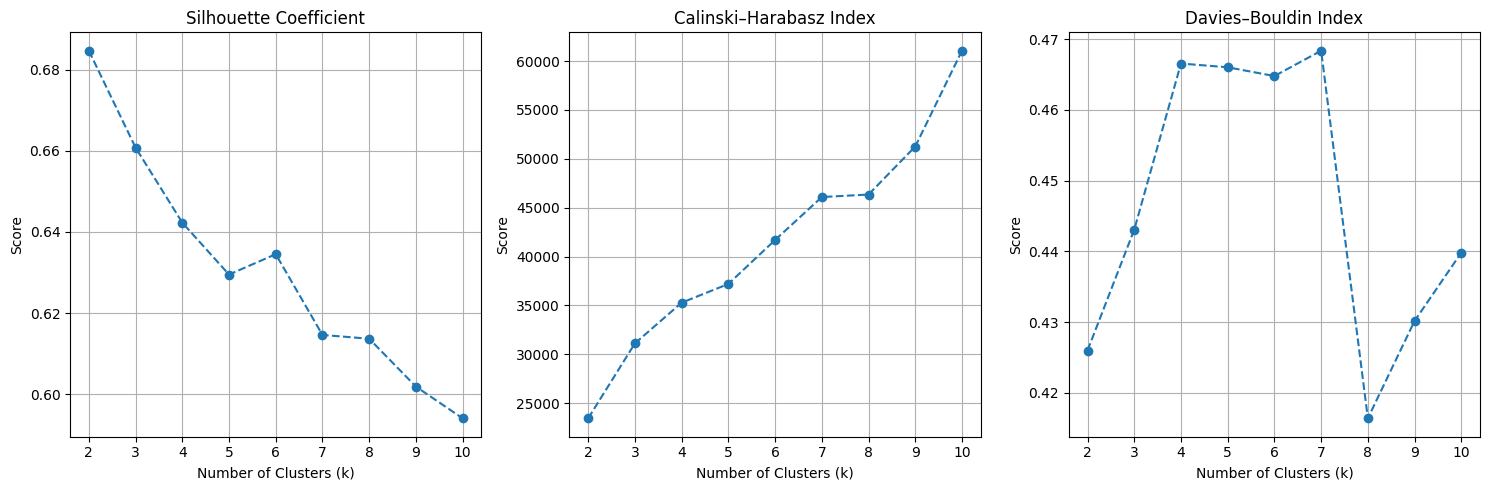

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    labels = km.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))
print("Silhouette Coefficient")
print(np.mean(silhouette_scores))
# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Calinski–Harabasz Index")
print(np.mean(calinski_harabasz_scores))
# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Davies–Bouldin Index")
print(np.mean(davies_bouldin_scores))
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation du Modèle avec RFM Score

Silhouette Coefficient
0.623005137513251
Calinski–Harabasz Index
40616.90307793478
Davies–Bouldin Index
0.4622935527591267


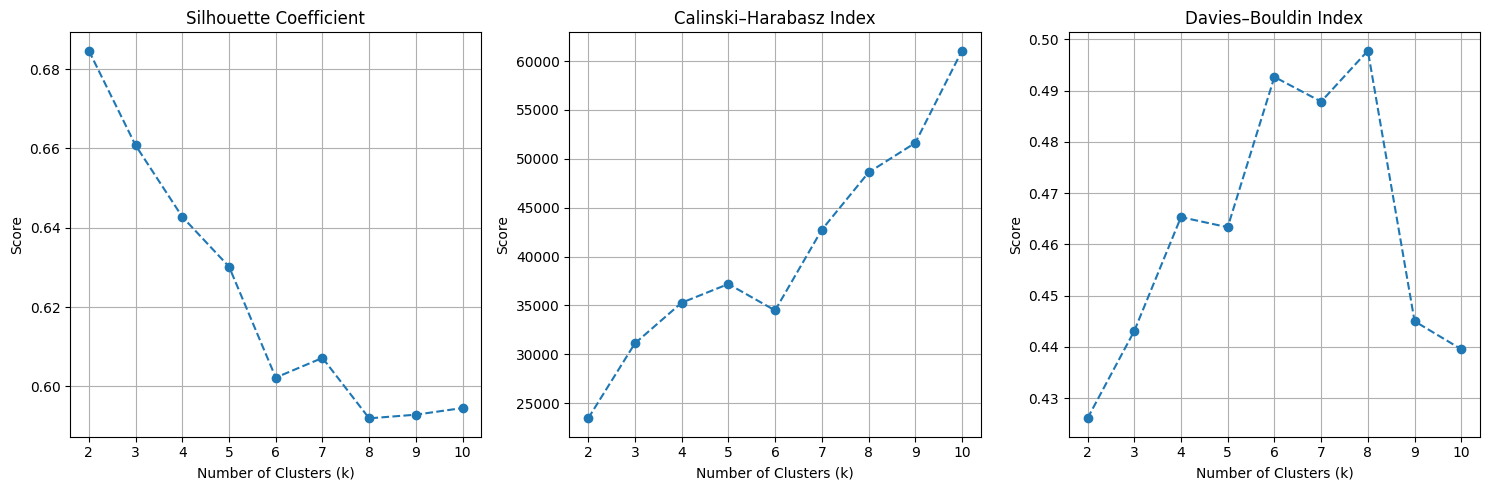

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km2 = KMeans(n_clusters=k, random_state=42).fit(X_rfm)
    labels = km2.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X_rfm, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_rfm, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_rfm, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))
print("Silhouette Coefficient")
print(np.mean(silhouette_scores))

# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Calinski–Harabasz Index")
print(np.mean(calinski_harabasz_scores))

# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Davies–Bouldin Index")
print(np.mean(davies_bouldin_scores))

# Davies–Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluate Model Performance with Stratified K Fold (for better "purchase" and "basket" events )

In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


In [29]:
import pytest
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

def test_clustering_with_stratified_kfold():
    """
    Test clustering performance using StratifiedKFold cross-validation.
    
    For clustering (unsupervised learning), we need to:
    1. First perform clustering on the entire dataset
    2. Use the resulting labels as a "pseudo-target" for stratification
    3. Evaluate how consistent the clustering is across folds
    """
    # Load or create sample data (replace with actual data loading)
    # This is a simplified example - you'll need to adapt to your actual dataframe
    try:
        df = pd.read_csv('path_to_your_data.csv')  # Replace with your data loading
        X = df.drop(columns=["last_event_time"])  # Adjust columns as needed
    except:
        # Create dummy data for testing if file not found
        X = pd.DataFrame(np.random.rand(100, 5), 
                        columns=['total_purchases', 'total_spent', 'avg_basket', 
                                'days_since_last_event', 'avg_time_between_events'])
    
    # 1. First perform clustering on entire dataset to get "pseudo-labels"
    # Choose K based on your prior analysis
    k = 5  # Replace with your optimal K value
    kmeans = KMeans(n_clusters=k, random_state=42)
    pseudo_labels = kmeans.fit_predict(X)
    
    # 2. Use StratifiedKFold with these pseudo-labels
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Track metrics across folds
    silhouette_scores = []
    calinski_scores = []
    davies_bouldin_scores = []
    
    # 3. Cross-validate
    for train_idx, test_idx in skf.split(X, pseudo_labels):
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        # Scale features (recommended for KMeans)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train on fold
        fold_kmeans = KMeans(n_clusters=k, random_state=42)
        fold_kmeans.fit(X_train_scaled)
        
        # Predict on test set
        test_labels = fold_kmeans.predict(X_test_scaled)
        
        # Only calculate metrics if we have at least 2 clusters in test set
        unique_labels = np.unique(test_labels)
        if len(unique_labels) >= 2:
            # Calculate metrics
            silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
            calinski_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
            davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
    
    # 4. Assert that metrics are consistent and within expected range
    assert len(silhouette_scores) > 0, "No valid silhouette scores calculated"
    avg_silhouette = np.mean(silhouette_scores)
    avg_calinski = np.mean(calinski_scores)
    avg_davies_bouldin = np.mean(davies_bouldin_scores)
    
    # Print results for inspection
    print(f"Cross-validated metrics over {len(silhouette_scores)} folds:")
    print(f"Average Silhouette Score: {avg_silhouette:.4f}")
    print(f"Average Calinski-Harabasz Score: {avg_calinski:.4f}")
    print(f"Average Davies-Bouldin Score: {avg_davies_bouldin:.4f}")
    
    # Check if metrics are within reasonable range
    assert -1 <= avg_silhouette <= 1, f"Silhouette score {avg_silhouette} outside valid range [-1,1]"
    assert avg_calinski > 0, f"Calinski-Harabasz score {avg_calinski} should be positive"
    assert avg_davies_bouldin > 0, f"Davies-Bouldin score {avg_davies_bouldin} should be positive"

### Interprétation des métriques d'évaluation de clustering

Les trois métriques que vous utilisez (**Silhouette Coefficient**, **Calinski-Harabasz Index** et **Davies-Bouldin Index**) sont des indicateurs standard pour évaluer la qualité d'un clustering. Voici comment les interpréter :

---

#### 1. Coefficient de Silhouette

- **Plage de valeurs** : -1 à 1  
- **Interprétation** :
    - **Proche de 1** : Les clusters sont bien définis et séparés
    - **Proche de 0** : Les clusters se chevauchent
    - **Négatif** : Points probablement assignés au mauvais cluster

- **Comment choisir le nombre optimal de clusters** :
    - Recherchez le nombre de clusters qui maximise le coefficient de Silhouette.
    - Si vous observez un pic à k=2, k=3 ou tout autre nombre, c'est probablement le nombre optimal de clusters.


#### 2. Indice de Calinski-Harabasz (ou Critère de Variance)

- **Plage de valeurs** : Plus grand est meilleur (pas de limite supérieure)  
- **Interprétation** :
    - Mesure le ratio entre la variance inter-clusters et la variance intra-clusters
    - Une valeur plus élevée indique des clusters plus denses et bien séparés

- **Comment choisir le nombre optimal de clusters** :
    - Cherchez le point où l'augmentation de l'indice ralentit significativement (point de coude)
    - Plus la valeur est élevée, meilleure est la séparation des clusters


#### 3. Indice de Davies-Bouldin

- **Plage de valeurs** : 0 et plus (pas de limite supérieure)  
- **Interprétation** :
    - Contrairement aux autres métriques, une valeur plus basse est meilleure
    - Mesure la similarité moyenne entre chaque cluster et celui qui lui ressemble le plus
    - 0 est la valeur idéale (clusters parfaitement séparés)

- **Comment choisir le nombre optimal de clusters** :
    - Recherchez le nombre de clusters qui minimise l'indice de Davies-Bouldin

---

### Comment prendre une décision globale

Pour déterminer le nombre optimal de clusters, vous devriez analyser ces trois métriques ensemble :

- **Silhouette Coefficient** : Choisissez le k qui donne la valeur maximale
- **Calinski-Harabasz** : Cherchez le "coude" dans la courbe où l'augmentation ralentit
- **Davies-Bouldin** : Choisissez le k qui donne la valeur minimale

Si les trois métriques suggèrent des valeurs différentes pour k, vous devrez faire un compromis en fonction de votre connaissance du domaine et de l'objectif de votre analyse.

> Par exemple, si le coefficient de Silhouette suggère k=3, l'indice de Calinski-Harabasz suggère k=6 et l'indice de Davies-Bouldin suggère k=4, vous pourriez choisir k=4 comme compromis raisonnable, ou explorer davantage ces trois options pour déterminer laquelle est la plus pertinente pour votre cas d'usage.

N'oubliez pas que ces métriques sont des indicateurs mathématiques — l'interprétabilité métier des clusters reste primordiale pour une segmentation utile.

## Analyse Multiple



Exécution du modèle RFM #1: RFM Base

RFM Analysis Completed
Total clients segmentés: 5989

Distribution des scores R:
R_score
1    5989
Name: count, dtype: int64

Distribution des scores F:
F_score
0    5064
1     838
2      87
Name: count, dtype: int64

Distribution des scores M:
M_score
0    4553
1     136
2    1300
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
100    4546
112     807
102     406
101     112
122      87
111      24
110       7
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des segments de clients:
Clients Perdus: 4665 clients (77.9%)
Clients Potentiels: 807 clients (13.5%)
Clients à Risque: 430 clients (7.2%)
Clients Fidèles: 87 clients (1

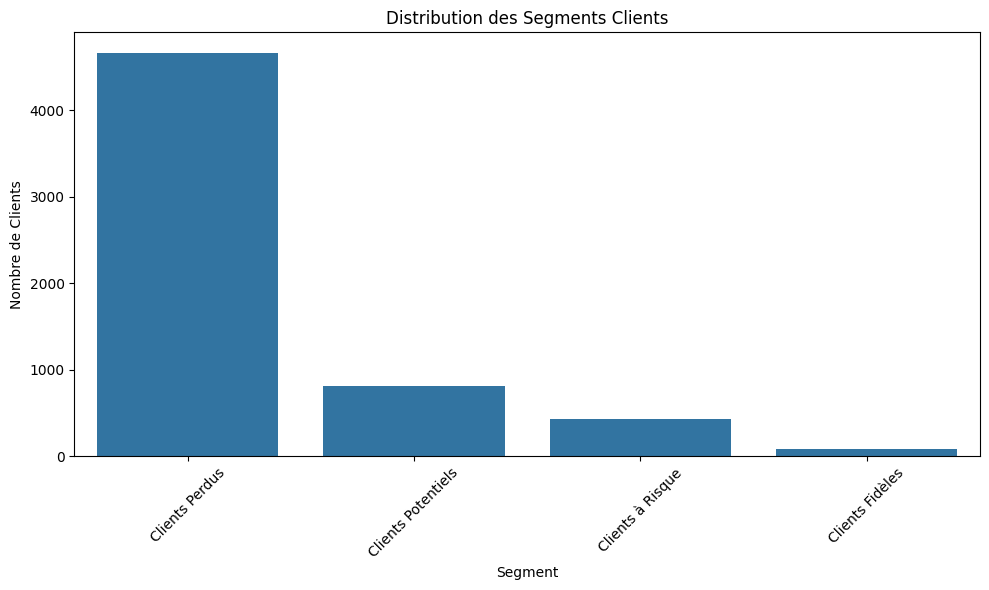

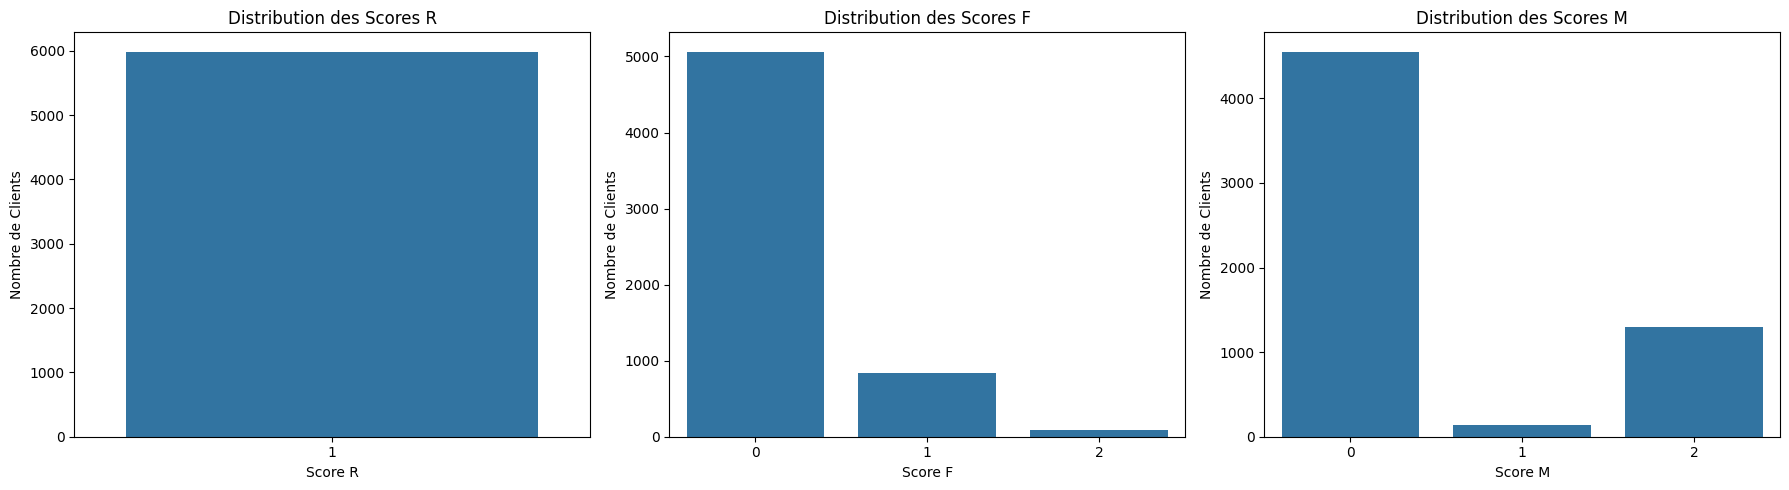


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Fidèles,1.23,20.90,7363.45,1.0,2.00,2.00,5.00,87
Clients Potentiels,1.34,3.35,1058.04,1.0,1.00,2.00,4.00,807
Clients à Risque,1.33,1.07,285.79,1.0,0.06,1.94,3.00,430
Clients Perdus,1.35,0.03,0.91,1.0,0.00,0.02,1.03,4665




Exécution du modèle RFM #2: RFM avec récence fine

RFM Analysis Completed
Total clients segmentés: 5989

Distribution des scores R:
R_score
2    5989
Name: count, dtype: int64

Distribution des scores F:
F_score
0    5064
1     838
2      87
Name: count, dtype: int64

Distribution des scores M:
M_score
0    4553
1     136
2    1300
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    4546
212     807
202     406
201     112
222      87
211      24
210       7
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 3: moins de 0.5
Score 2: entre 0.5 et 2
Score 1: entre 2 et 6
Score 0: plus de 6

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des segments de clients:
Clients Perdus: 4546 clients (75.9%)
Clients Fidèles: 894 clients (14.9%)
Clients Potentiels: 430 clients

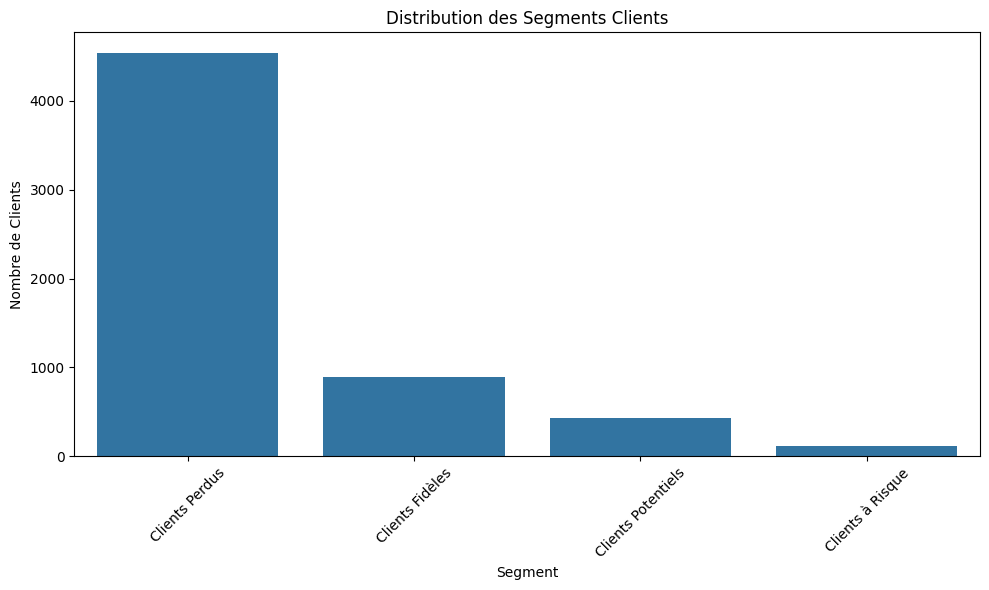

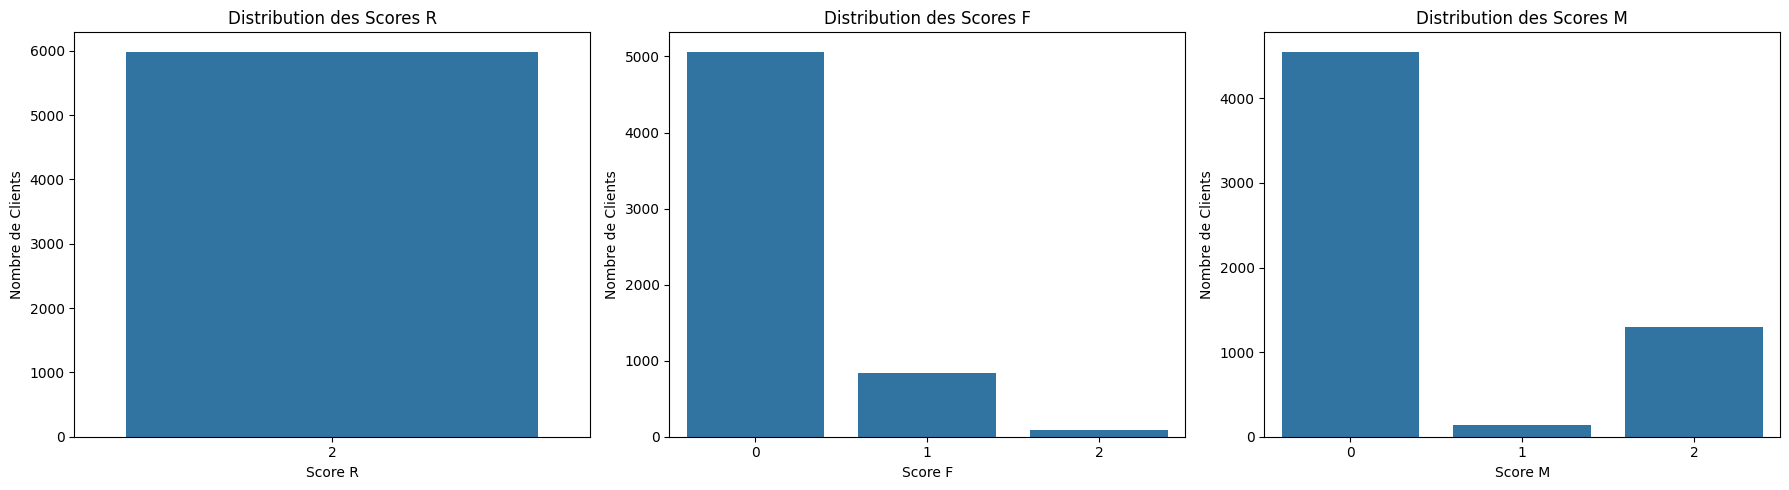


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Fidèles,1.33,5.06,1671.65,2.0,1.10,2.00,5.1,894
Clients Potentiels,1.33,1.07,285.79,2.0,0.06,1.94,4.0,430
Clients à Risque,1.29,1.06,33.35,2.0,0.06,0.94,3.0,119
Clients Perdus,1.35,0.01,0.06,2.0,0.00,0.00,2.0,4546




Exécution du modèle RFM #3: RFM avec fréquence fine

RFM Analysis Completed
Total clients segmentés: 5989

Distribution des scores R:
R_score
1    5989
Name: count, dtype: int64

Distribution des scores F:
F_score
0    4518
1     952
2     432
3      87
Name: count, dtype: int64

Distribution des scores M:
M_score
0    4553
1     136
2    1300
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
100    4518
112     786
122     427
111     131
132      87
110      35
121       5
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 1
Score 1: entre 1 et 3
Score 2: entre 3 et 10
Score 3: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des segments de clients:
Clients Perdus: 4553 clients (76.0%)
Clients à Risque: 922 clients (15.4%)
Clients Potentiels: 51

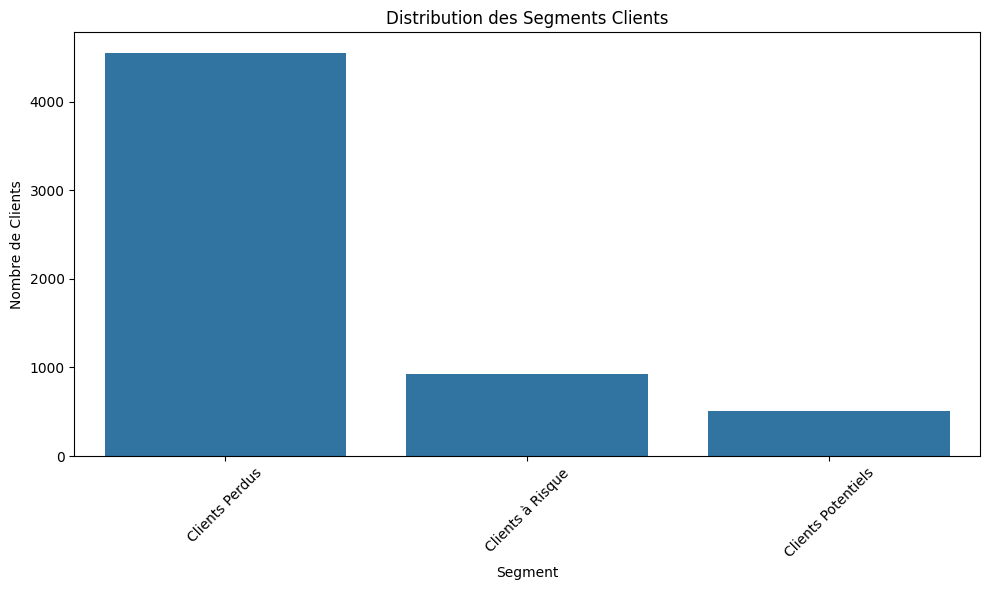

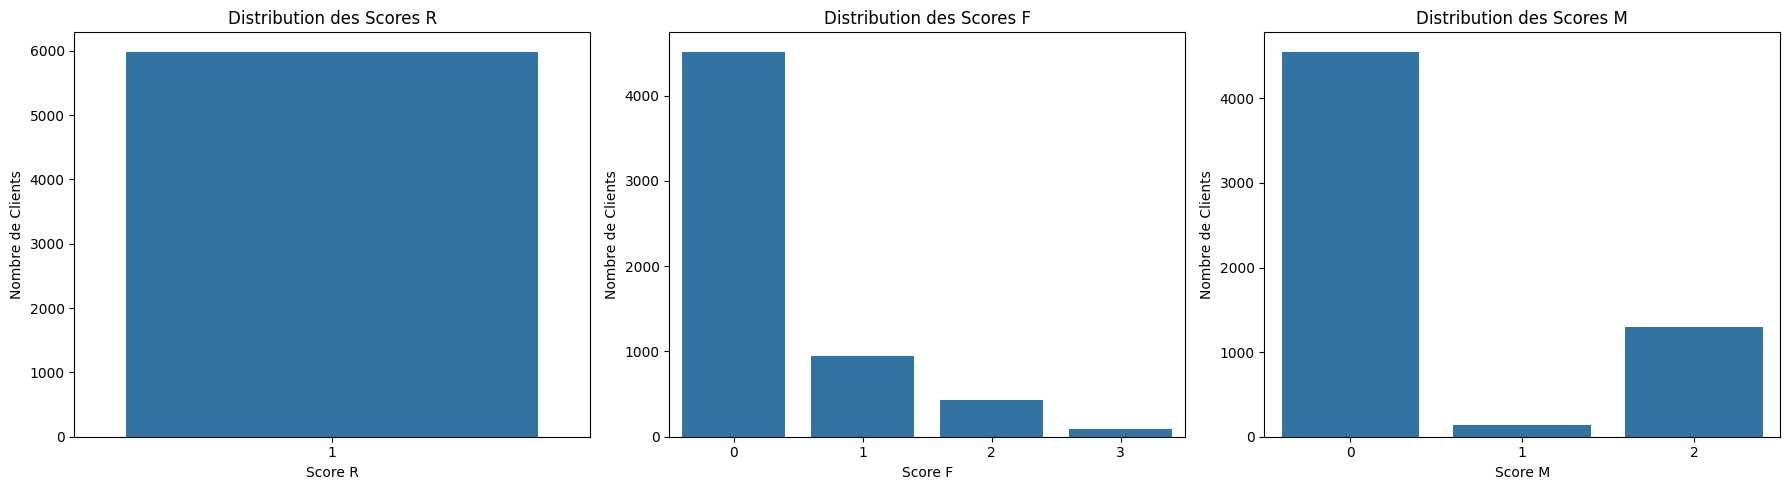


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Potentiels,1.30,7.32,2418.03,1.0,2.17,2.00,5.17,514
Clients à Risque,1.34,1.45,410.34,1.0,1.01,1.85,3.86,922
Clients Perdus,1.35,0.01,0.09,1.0,0.01,0.00,1.01,4553




Exécution du modèle RFM #4: RFM avec montant fin

RFM Analysis Completed
Total clients segmentés: 5989

Distribution des scores R:
R_score
1    5989
Name: count, dtype: int64

Distribution des scores F:
F_score
0    5064
1     838
2      87
Name: count, dtype: int64

Distribution des scores M:
M_score
0    4533
1      80
2     158
3    1218
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
100    4533
113     773
103     358
102     111
123      87
101      62
112      47
111      18
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 10€
Score 1: entre 10€ et 30€
Score 2: entre 30€ et 75€
Score 3: plus de 75€

Distribution des segments de clients:
Clients Perdus: 4595 clients (76.7%)
Clients Potentiels: 773 clients (12.9%)
Clients

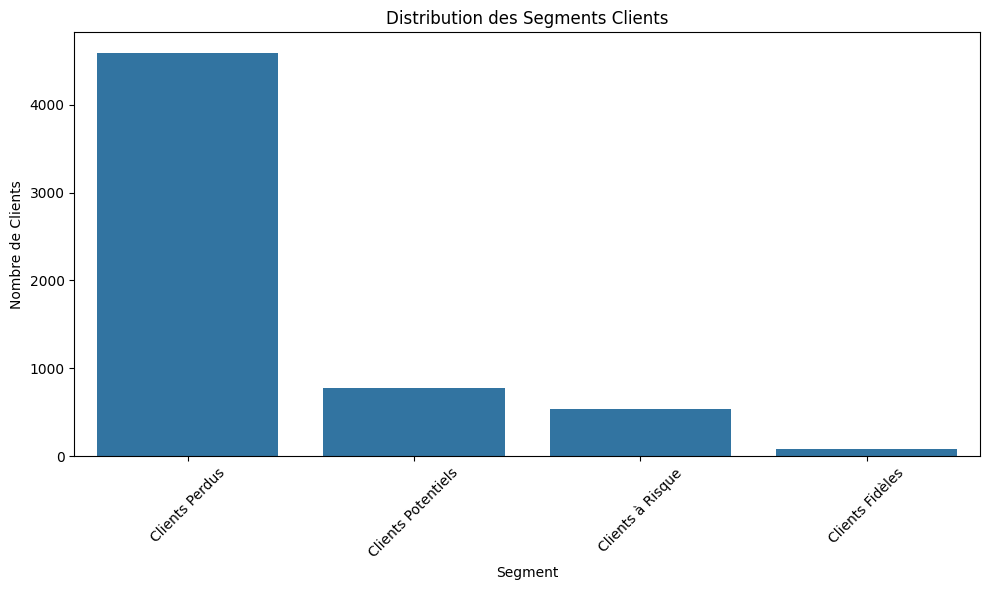

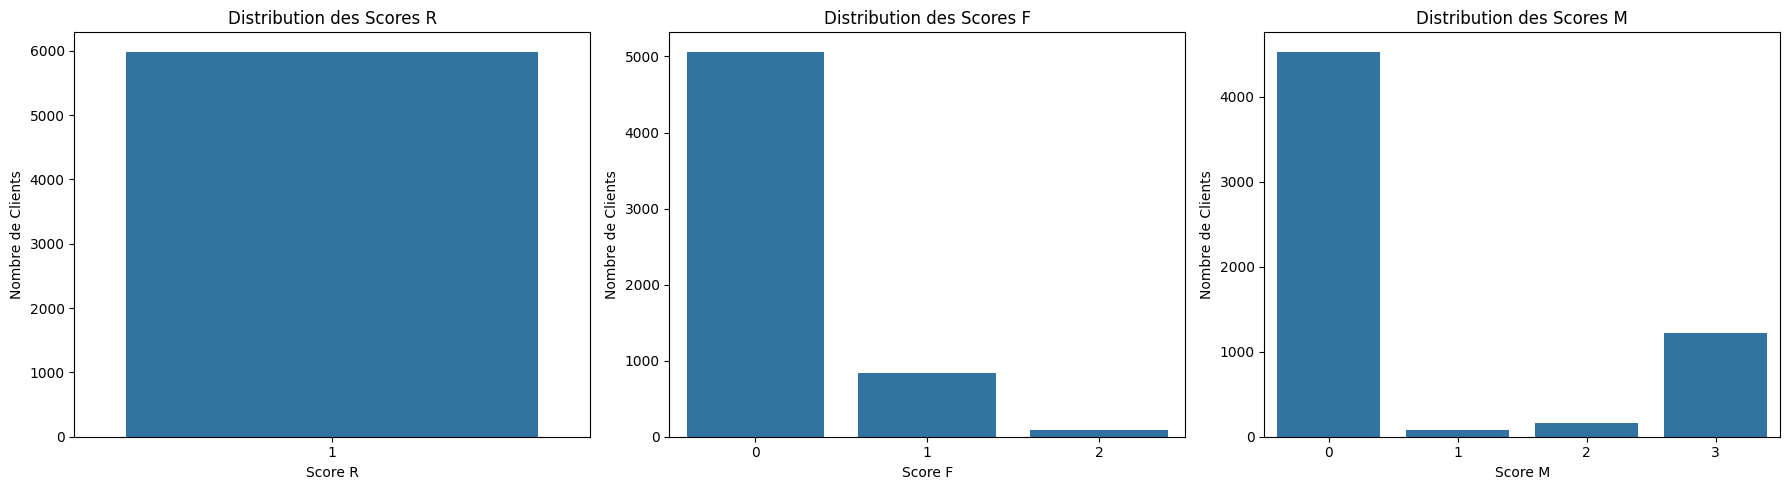


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Fidèles,1.23,20.90,7363.45,1.0,2.00,3.00,6.00,87
Clients Potentiels,1.34,3.40,1101.81,1.0,1.00,3.00,5.00,773
Clients à Risque,1.33,1.15,239.19,1.0,0.12,2.64,3.76,534
Clients Perdus,1.35,0.02,0.34,1.0,0.00,0.01,1.01,4595




Exécution du modèle RFM #5: RFM complet

RFM Analysis Completed
Total clients segmentés: 5989

Distribution des scores R:
R_score
2    5989
Name: count, dtype: int64

Distribution des scores F:
F_score
0    4518
1     952
2     432
3      87
Name: count, dtype: int64

Distribution des scores M:
M_score
0    4533
1      80
2     158
3    1218
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    4518
213     709
223     422
212     151
233      87
211      77
210      15
222       7
221       3
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 3: moins de 0.5
Score 2: entre 0.5 et 2
Score 1: entre 2 et 6
Score 0: plus de 6

FRÉQUENCE (total_purchases):
Score 0: moins de 1
Score 1: entre 1 et 3
Score 2: entre 3 et 10
Score 3: plus de 10

MONTANT (total_spent):
Score 0: moins de 10€
Score 1: entre 10€ et 30€
Score 2: entre 30€ et 75€
Score 3: plus de 75€

Distribution des segments de clients:
Inactifs: 4518 clients 

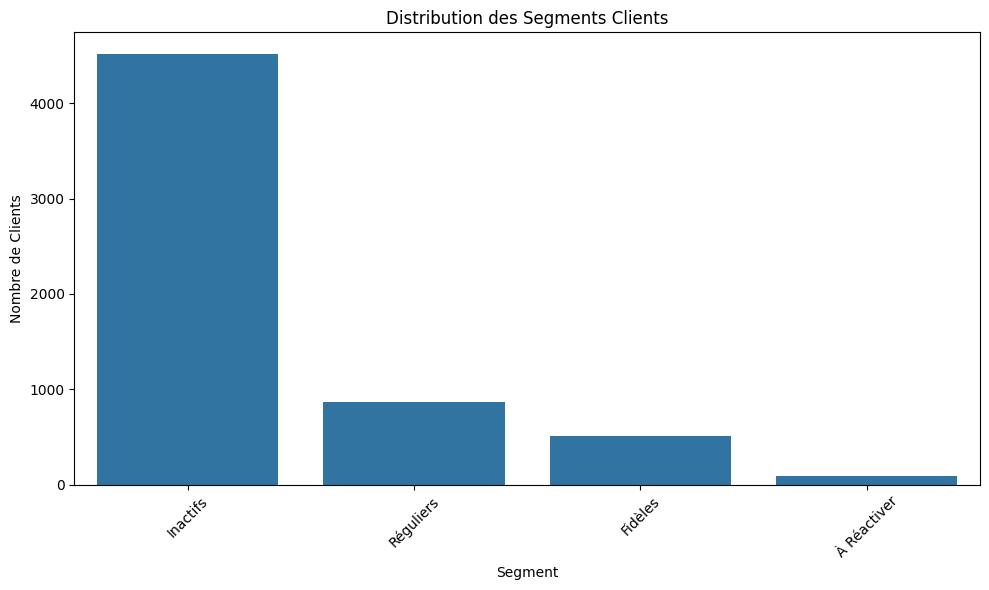

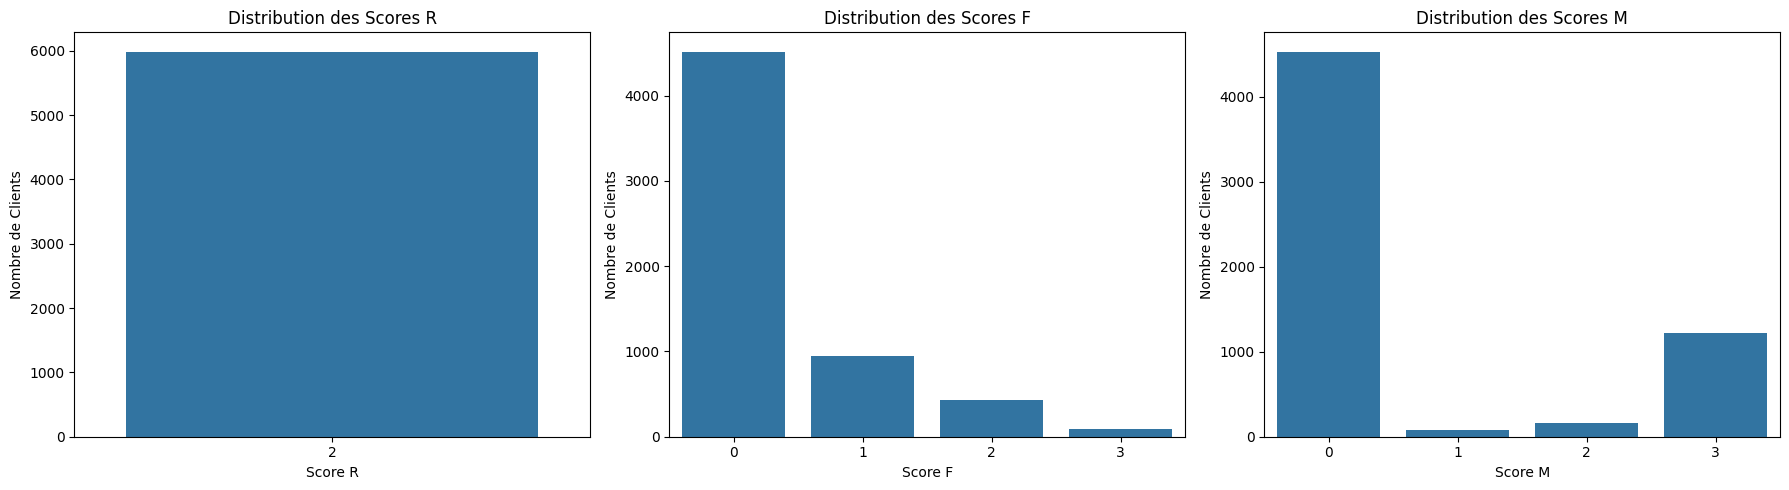


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Fidèles,1.30,7.35,2441.14,2.0,2.17,3.00,7.17,509
Réguliers,1.35,1.48,433.55,2.0,1.01,2.81,5.82,870
À Réactiver,1.31,1.16,20.42,2.0,1.00,0.84,3.84,92
Inactifs,1.35,0.00,0.00,2.0,0.00,0.00,2.00,4518




Récapitulatif des modèles RFM générés:
1. RFM Base:
   - Nombre de segments distincts: 4
   - Segment le plus représenté: 'Clients Perdus' (4665 clients, 77.9%)
   - Dimensions: R [3 niveaux], F [3 niveaux], M [3 niveaux]

2. RFM avec récence fine:
   - Nombre de segments distincts: 4
   - Segment le plus représenté: 'Clients Perdus' (4546 clients, 75.9%)
   - Dimensions: R [4 niveaux], F [3 niveaux], M [3 niveaux]

3. RFM avec fréquence fine:
   - Nombre de segments distincts: 3
   - Segment le plus représenté: 'Clients Perdus' (4553 clients, 76.0%)
   - Dimensions: R [3 niveaux], F [4 niveaux], M [3 niveaux]

4. RFM avec montant fin:
   - Nombre de segments distincts: 4
   - Segment le plus représenté: 'Clients Perdus' (4595 clients, 76.7%)
   - Dimensions: R [3 niveaux], F [3 niveaux], M [4 niveaux]

5. RFM complet:
   - Nombre de segments distincts: 4
   - Segment le plus représenté: 'Inactifs' (4518 clients, 75.4%)
   - Dimensions: R [4 niveaux], F [4 niveaux], M [4 niveaux]



In [30]:
# Liste pour stocker les différents résultats de segmentation RFM
rfm_segments_list = []

# Définir 5 combinaisons d'hyperparamètres différents
hyperparameter_sets = [
    {
        # Jeu 1: Paramètres de base (les mêmes que dans votre exemple)
        "name": "RFM Base",
        "r_thresholds": [1, 5],
        "r_scores": [2, 1, 0],
        "f_thresholds": [2, 10],
        "f_scores": [0, 1, 2],
        "m_thresholds": [20, 50],
        "m_scores": [0, 1, 2],
        "segment_thresholds": [0, 3, 4, 5, 6],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 2: Plus de granularité dans la récence
        "name": "RFM avec récence fine",
        "r_thresholds": [0.5, 2, 6],
        "r_scores": [3, 2, 1, 0],
        "f_thresholds": [2, 10],
        "f_scores": [0, 1, 2],
        "m_thresholds": [20, 50],
        "m_scores": [0, 1, 2],
        "segment_thresholds": [0, 3, 4, 5, 7],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 3: Plus de granularité dans la fréquence
        "name": "RFM avec fréquence fine",
        "r_thresholds": [1, 5],
        "r_scores": [2, 1, 0],
        "f_thresholds": [1, 3, 10],
        "f_scores": [0, 1, 2, 3],
        "m_thresholds": [20, 50],
        "m_scores": [0, 1, 2],
        "segment_thresholds": [0, 3, 5, 7, 8],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 4: Plus de granularité dans le montant
        "name": "RFM avec montant fin",
        "r_thresholds": [1, 5],
        "r_scores": [2, 1, 0],
        "f_thresholds": [2, 10],
        "f_scores": [0, 1, 2],
        "m_thresholds": [10, 30, 75],
        "m_scores": [0, 1, 2, 3],
        "segment_thresholds": [0, 3, 5, 6, 8],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 5: Ensemble complet avec granularité sur toutes les dimensions
        "name": "RFM complet",
        "r_thresholds": [0.5, 2, 6],
        "r_scores": [3, 2, 1, 0],
        "f_thresholds": [1, 3, 10],
        "f_scores": [0, 1, 2, 3],
        "m_thresholds": [10, 30, 75],
        "m_scores": [0, 1, 2, 3],
        "segment_thresholds": [0, 3, 5, 7, 9],
        "segment_names": ['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']
    }
]

# Exécuter l'analyse RFM pour chaque jeu d'hyperparamètres
for i, params in enumerate(hyperparameter_sets):
    print(f"\n\n{'='*50}")
    print(f"Exécution du modèle RFM #{i+1}: {params['name']}")
    print(f"{'='*50}\n")
    
    # Exécuter l'analyse avec les hyperparamètres spécifiés
    result_df = perform_rfm_analysis(
        user_segments_df_tmspt,
        r_column='months_since_last_event',
        r_thresholds=params['r_thresholds'],
        r_scores=params['r_scores'],
        f_column='total_purchases',
        f_thresholds=params['f_thresholds'],
        f_scores=params['f_scores'],
        m_column='total_spent',
        m_thresholds=params['m_thresholds'],
        m_scores=params['m_scores'],
        segment_thresholds=params['segment_thresholds'],
        segment_names=params['segment_names'],
        visualize=True  # Vous pouvez changer à False si vous ne voulez pas les graphiques pour chaque itération
    )
    
    # Stocker le résultat dans la liste avec des métadonnées
    rfm_segments_list.append({
        "name": params["name"],
        "params": params,
        "result": result_df
    })

# Afficher un récapitulatif des différents modèles
print("\n\nRécapitulatif des modèles RFM générés:")
print("=" * 80)
for i, model in enumerate(rfm_segments_list):
    n_segments = model["result"]["segment"].nunique()
    top_segment = model["result"]["segment"].value_counts().index[0]
    top_segment_count = model["result"]["segment"].value_counts().iloc[0]
    top_segment_pct = (top_segment_count / len(model["result"])) * 100
    
    print(f"{i+1}. {model['name']}:")
    print(f"   - Nombre de segments distincts: {n_segments}")
    print(f"   - Segment le plus représenté: '{top_segment}' ({top_segment_count} clients, {top_segment_pct:.1f}%)")
    print(f"   - Dimensions: R [{len(model['params']['r_scores'])} niveaux], " +
          f"F [{len(model['params']['f_scores'])} niveaux], " +
          f"M [{len(model['params']['m_scores'])} niveaux]")
    print()

# Pour accéder ultérieurement à un modèle spécifique:
# model_3 = rfm_segments_list[2]["result"]

In [31]:
rfm_segments_list

[{'name': 'RFM Base',
  'params': {'name': 'RFM Base',
   'r_thresholds': [1, 5],
   'r_scores': [2, 1, 0],
   'f_thresholds': [2, 10],
   'f_scores': [0, 1, 2],
   'm_thresholds': [20, 50],
   'm_scores': [0, 1, 2],
   'segment_thresholds': [0, 3, 4, 5, 6],
   'segment_names': ['Clients Perdus',
    'Clients à Risque',
    'Clients Potentiels',
    'Clients Fidèles',
    'Champions']},
  'result':         user_id  total_events  total_views  total_purchases  \
  0     530092249            10         10.0              0.0   
  1     609755176            24         23.0              0.0   
  2     616080818            19         19.0              0.0   
  3     609558338            11         11.0              0.0   
  4     518552508            14          5.0              0.0   
  ...         ...           ...          ...              ...   
  5984  545582731            14         14.0              0.0   
  5985  523896882            11         11.0              0.0   
  5986  5228399

--------------------------------------------------------------
-------- MODEL ----------  RFM Base
-------- PARAMS ----------  {'name': 'RFM Base', 'r_thresholds': [1, 5], 'r_scores': [2, 1, 0], 'f_thresholds': [2, 10], 'f_scores': [0, 1, 2], 'm_thresholds': [20, 50], 'm_scores': [0, 1, 2], 'segment_thresholds': [0, 3, 4, 5, 6], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.623005137513251
Calinski–Harabasz Index
40616.90307793478
Davies–Bouldin Index
0.4622935527591267


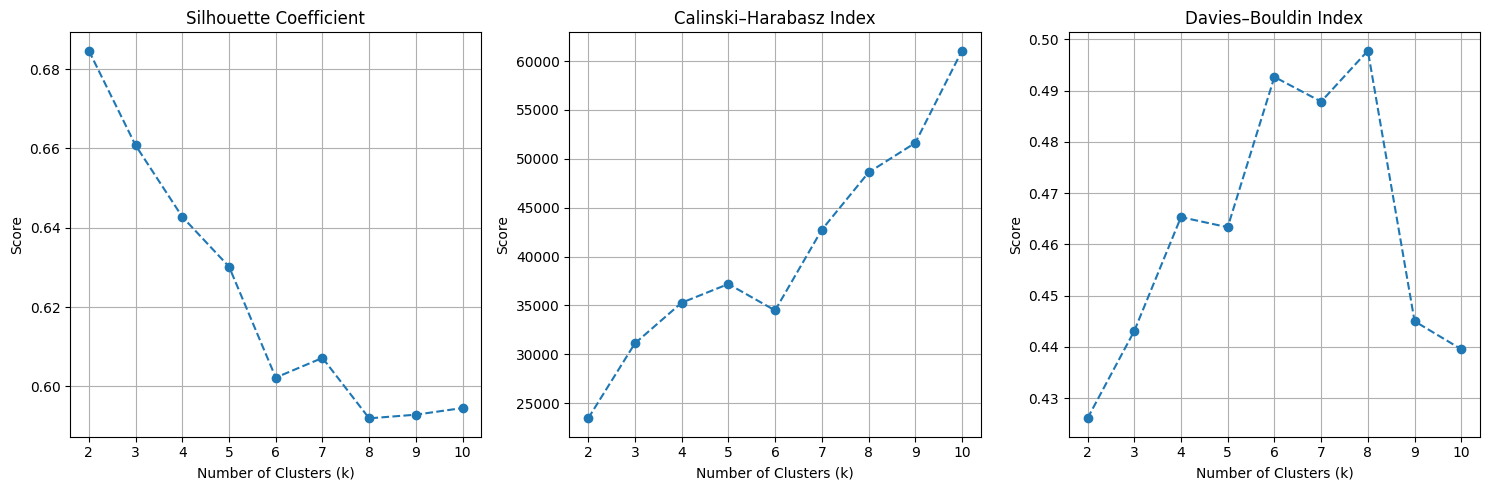

--------------------------------------------------------------
-------- MODEL ----------  RFM avec récence fine
-------- PARAMS ----------  {'name': 'RFM avec récence fine', 'r_thresholds': [0.5, 2, 6], 'r_scores': [3, 2, 1, 0], 'f_thresholds': [2, 10], 'f_scores': [0, 1, 2], 'm_thresholds': [20, 50], 'm_scores': [0, 1, 2], 'segment_thresholds': [0, 3, 4, 5, 7], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.6230051375131823
Calinski–Harabasz Index
40616.90307793478
Davies–Bouldin Index
0.4622935527590668


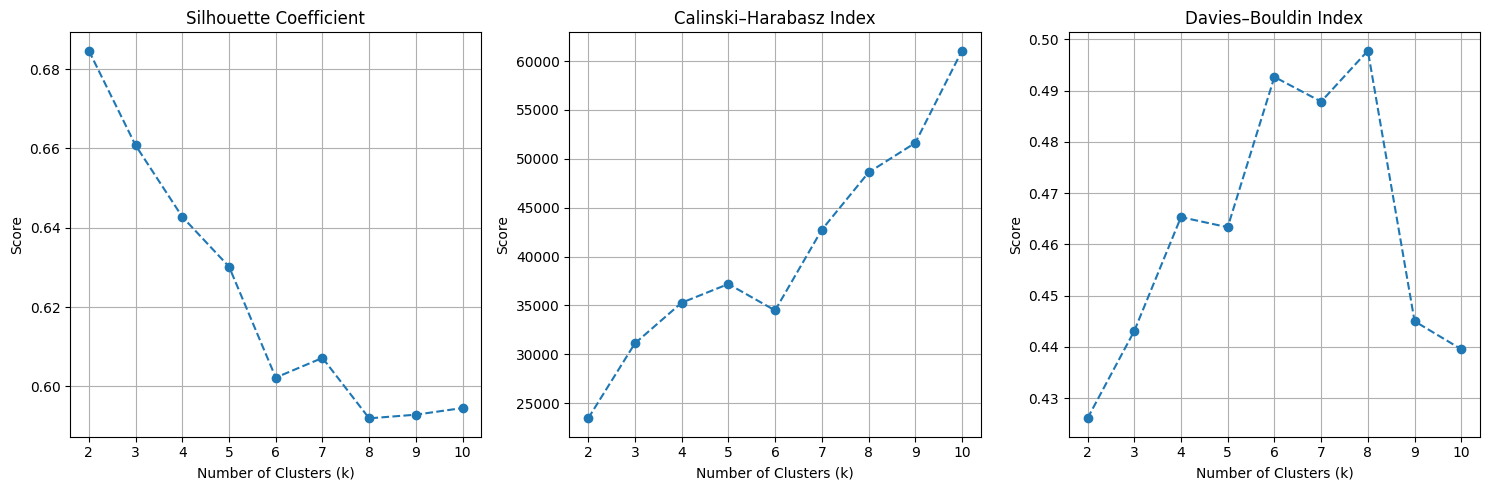

--------------------------------------------------------------
-------- MODEL ----------  RFM avec fréquence fine
-------- PARAMS ----------  {'name': 'RFM avec fréquence fine', 'r_thresholds': [1, 5], 'r_scores': [2, 1, 0], 'f_thresholds': [1, 3, 10], 'f_scores': [0, 1, 2, 3], 'm_thresholds': [20, 50], 'm_scores': [0, 1, 2], 'segment_thresholds': [0, 3, 5, 7, 8], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.6230051375131954
Calinski–Harabasz Index
40616.903077933384
Davies–Bouldin Index
0.4622935527591697


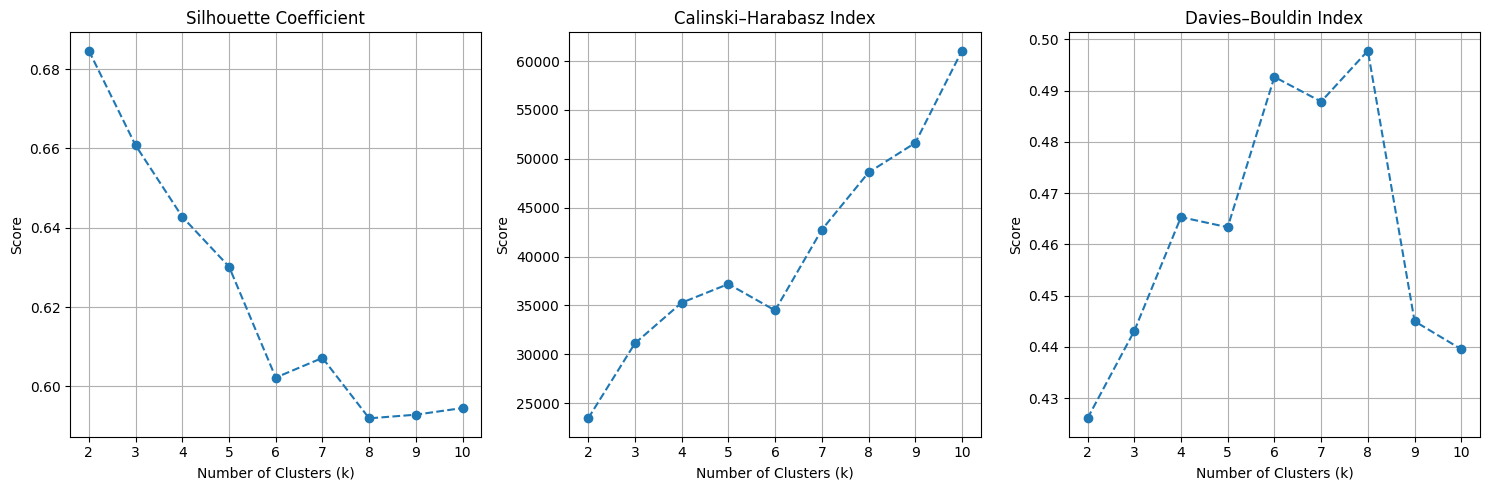

--------------------------------------------------------------
-------- MODEL ----------  RFM avec montant fin
-------- PARAMS ----------  {'name': 'RFM avec montant fin', 'r_thresholds': [1, 5], 'r_scores': [2, 1, 0], 'f_thresholds': [2, 10], 'f_scores': [0, 1, 2], 'm_thresholds': [10, 30, 75], 'm_scores': [0, 1, 2, 3], 'segment_thresholds': [0, 3, 5, 6, 8], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.623005137513184
Calinski–Harabasz Index
40616.90307793234
Davies–Bouldin Index
0.462293552759226


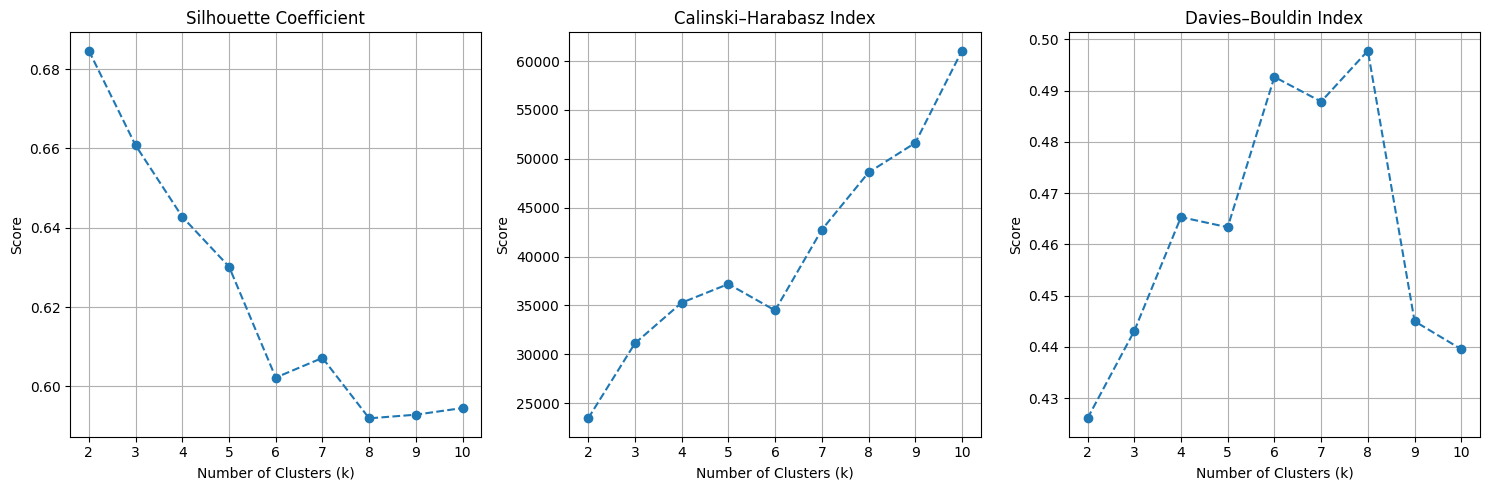

--------------------------------------------------------------
-------- MODEL ----------  RFM complet
-------- PARAMS ----------  {'name': 'RFM complet', 'r_thresholds': [0.5, 2, 6], 'r_scores': [3, 2, 1, 0], 'f_thresholds': [1, 3, 10], 'f_scores': [0, 1, 2, 3], 'm_thresholds': [10, 30, 75], 'm_scores': [0, 1, 2, 3], 'segment_thresholds': [0, 3, 5, 7, 9], 'segment_names': ['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']}
Silhouette Coefficient
0.6230051375128914
Calinski–Harabasz Index
40616.90307793063
Davies–Bouldin Index
0.4622935527593461


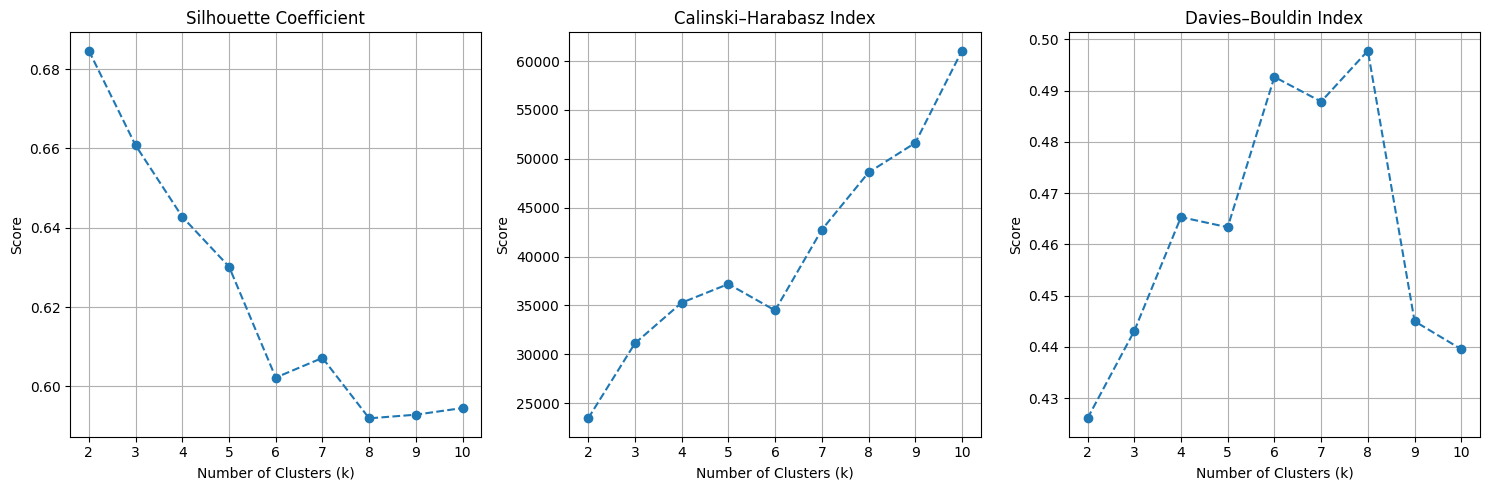

In [32]:
for model in rfm_segments_list:
    params = model['params']
    result_df = model['result']
    
    # Define the range of clusters to evaluate
    ks = range(2, 11)

    # Initialize lists to store the scores
    silhouette_scores = []
    calinski_harabasz_scores = []
    davies_bouldin_scores = []

    # Prepare the data - drop columns that shouldn't be used for clustering
    X_model = result_df.drop(columns=["segment", "last_event_time", "RFM_segment"])

    # Evaluate clustering for each k
    for k in ks:
        km2 = KMeans(n_clusters=k, random_state=42).fit(X_model)
        labels = km2.labels_
        
        # Compute the metrics
        silhouette_scores.append(silhouette_score(X_model, labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X_model, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_model, labels))
    
    print("--------------------------------------------------------------")
    print(f"-------- MODEL ----------  {model['name']}")
    print(f"-------- PARAMS ----------  {model['params']}")
    # Plot the metrics
    plt.figure(figsize=(15, 5))
    print("Silhouette Coefficient")
    print(np.mean(silhouette_scores))

    # Silhouette Coefficient
    plt.subplot(1, 3, 1)
    plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
    plt.title("Silhouette Coefficient")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")
    plt.grid(True)
    print("Calinski–Harabasz Index")
    print(np.mean(calinski_harabasz_scores))

    # Calinski–Harabasz Index
    plt.subplot(1, 3, 2)
    plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
    plt.title("Calinski–Harabasz Index")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")
    plt.grid(True)
    print("Davies–Bouldin Index")
    print(np.mean(davies_bouldin_scores))

    # Davies–Bouldin Index
    plt.subplot(1, 3, 3)
    plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
    plt.title("Davies–Bouldin Index")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Stratified K Fold

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


In [34]:
import pytest
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

def test_clustering_with_stratified_kfold():
    """
    Test clustering performance using StratifiedKFold cross-validation.
    
    For clustering (unsupervised learning), we need to:
    1. First perform clustering on the entire dataset
    2. Use the resulting labels as a "pseudo-target" for stratification
    3. Evaluate how consistent the clustering is across folds
    """
    # Load or create sample data (replace with actual data loading)
    # This is a simplified example - you'll need to adapt to your actual dataframe
    try:
        df = pd.read_csv('path_to_your_data.csv')  # Replace with your data loading
        X = df.drop(columns=["last_event_time"])  # Adjust columns as needed
    except:
        # Create dummy data for testing if file not found
        X = pd.DataFrame(np.random.rand(100, 5), 
                        columns=['total_purchases', 'total_spent', 'avg_basket', 
                                'days_since_last_event', 'avg_time_between_events'])
    
    # 1. First perform clustering on entire dataset to get "pseudo-labels"
    # Choose K based on your prior analysis
    k = 5  # Replace with your optimal K value
    kmeans = KMeans(n_clusters=k, random_state=42)
    pseudo_labels = kmeans.fit_predict(X)
    
    # 2. Use StratifiedKFold with these pseudo-labels
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Track metrics across folds
    silhouette_scores = []
    calinski_scores = []
    davies_bouldin_scores = []
    
    # 3. Cross-validate
    for train_idx, test_idx in skf.split(X, pseudo_labels):
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        # Scale features (recommended for KMeans)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train on fold
        fold_kmeans = KMeans(n_clusters=k, random_state=42)
        fold_kmeans.fit(X_train_scaled)
        
        # Predict on test set
        test_labels = fold_kmeans.predict(X_test_scaled)
        
        # Only calculate metrics if we have at least 2 clusters in test set
        unique_labels = np.unique(test_labels)
        if len(unique_labels) >= 2:
            # Calculate metrics
            silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
            calinski_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
            davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
    
    # 4. Assert that metrics are consistent and within expected range
    assert len(silhouette_scores) > 0, "No valid silhouette scores calculated"
    avg_silhouette = np.mean(silhouette_scores)
    avg_calinski = np.mean(calinski_scores)
    avg_davies_bouldin = np.mean(davies_bouldin_scores)
    
    # Print results for inspection
    print(f"Cross-validated metrics over {len(silhouette_scores)} folds:")
    print(f"Average Silhouette Score: {avg_silhouette:.4f}")
    print(f"Average Calinski-Harabasz Score: {avg_calinski:.4f}")
    print(f"Average Davies-Bouldin Score: {avg_davies_bouldin:.4f}")
    
    # Check if metrics are within reasonable range
    assert -1 <= avg_silhouette <= 1, f"Silhouette score {avg_silhouette} outside valid range [-1,1]"
    assert avg_calinski > 0, f"Calinski-Harabasz score {avg_calinski} should be positive"
    assert avg_davies_bouldin > 0, f"Davies-Bouldin score {avg_davies_bouldin} should be positive"

In [33]:
con.close()